In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping,ReduceLROnPlateau


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sanan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [56]:
import warnings
warnings.filterwarnings('ignore')

In [57]:
df = pd.read_csv('emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


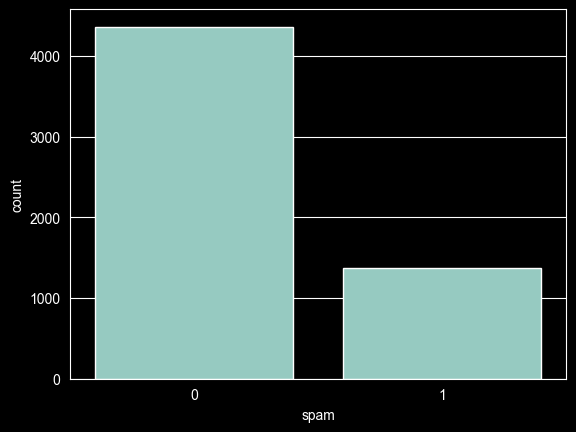

In [59]:
sns.countplot(x=df['spam'], data=df)
plt.show()


In [60]:
spam_msg = df[df['spam'] == 1]
norm_msg =  df[df['spam'] == 0]

norm_msg_balanced = norm_msg.sample(n=len(spam_msg), random_state=42)

balanced_data = pd.concat([spam_msg, norm_msg_balanced]).reset_index(drop=True)
balanced_data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


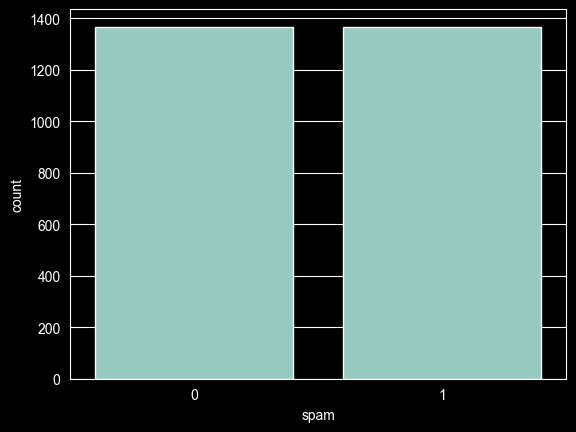

In [61]:
sns.countplot(x=balanced_data['spam'], data=balanced_data)
plt.show()

In [62]:
stop_words = set(stopwords.words('english'))

def remove_text(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word.lower() not in stop_words:
            filtered_words.append(word)

    return "".join(filtered_words)

In [63]:
balanced_data['text'] = balanced_data['text'].apply(remove_text)

balanced_data.head()

,text,spam
0,Subject:naturallyirresistiblecorporateidentity...,1
1,Subject:stocktradinggunslingerfannymerrillmuzo...,1
2,Subject:unbelievablenewhomesmadeeasyimwantings...,1
3,Subject:4colorprintingspecialrequestadditional...,1
4,"Subject:money,getsoftwarecds!softwarecompatibi...",1


In [64]:
y = balanced_data['spam'].astype('int')
X = balanced_data['text']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

In [71]:
print("Train X shape:", train_sequences.shape)
print("Train y shape:", y_train.shape)


Train X shape: (2188, 100)
Train y shape: (2188,)


In [66]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 32)        │     1,625,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,449 (6.21 MB)

 Trainable params: 1,628,449 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
print(train_sequences.shape)
print(y_train.shape)

print(test_sequences.shape)
print(y_test.shape)


(2188, 100)
(2188,)
(548, 100)
(548,)


In [72]:
es = EarlyStopping(
    patience=3,
    monitor='val_accuracy',
    restore_best_weights=True
)

lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    factor=0.5,
    verbose=1
)

history = model.fit(
    train_sequences, y_train,
    validation_data=(test_sequences, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6421 - loss: 0.6531 - val_accuracy: 0.5620 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7660 - loss: 0.5132 - val_accuracy: 0.7865 - val_loss: 0.4560 - learning_rate: 0.0010
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8199 - loss: 0.4267 - val_accuracy: 0.7883 - val_loss: 0.4414 - learning_rate: 0.0010
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8222 - loss: 0.4124 - val_accuracy: 0.7883 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8236 - loss: 0.4041
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8236 - loss: 0.4041 - val_accuracy: 0.7865 - val_loss: 0.4348 - learning_rate: 0.0010
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8240 - loss: 0.4000 - val_accu

In [74]:
test_loss, test_accuracy = model.evaluate(test_sequences, y_test)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7883 - loss: 0.4414
Test Loss : 0.44144150614738464
Test Accuracy : 0.7883211970329285


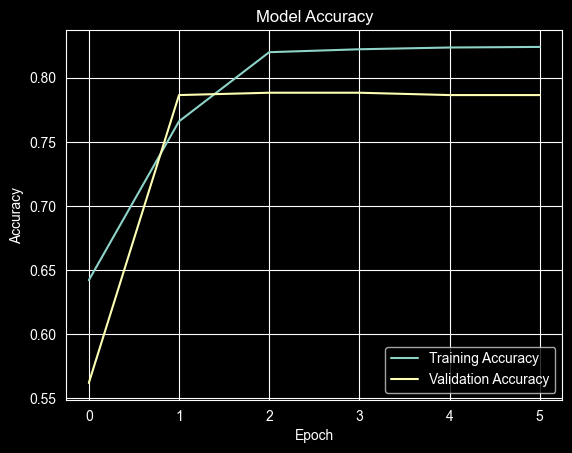

In [75]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()